# Checkpoint 4 — Questão 1: Logística de emergência após eventos climáticos

**Integrantes:** Felipe Bernardes (RM564360) · Guilherme Romero (RM564431)

Este notebook executa o código de `src/` — nenhum algoritmo é implementado aqui, apenas chamado e explicado.
O modelo completo e as justificativas estão no `README.md` e em `docs/analise_complexidade.md`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display
from src.config import SEED, INTEGRANTES, FIG_DIR
pd.set_option("display.max_rows", 60)
print("SEED =", SEED)
for nome, rm in INTEGRANTES:
    print(f"  {nome} — {rm}")

SEED = 564360
  Felipe Bernardes — RM564360
  Guilherme Romero — RM564431


## Parte A — Construção do problema

A instância é gerada por `src/dados_q1.py` com `random.Random(SEED)` e salva em `data/`:
`problema1_pontos.csv` (vértices), `problema1.csv` (arestas) e `problema1_parametros.json` (capacidade).

* 1 centro de distribuição + 20 pontos em um quadrado de 100 × 100 km;
* cada ponto ligado aos 3 vizinhos mais próximos → grafo esparso, **não** completo;
* peso = distância euclidiana × sinuosidade (1,00–1,35);
* 15% das vias bloqueadas (enchente/deslizamento);
* benefício = pessoas/10 × fator(prioridade), com fator = {1: 1, 2: 1,5, 3: 2, 4: 3, 5: 4};
* capacidade do veículo = 45% da demanda total → nem todos cabem.

In [2]:
from src.questao1 import obter_instancia, itens_da_instancia
from src.caminhos import MatrizDistancias

grafo, capacidade = obter_instancia()
matriz = MatrizDistancias(grafo)
pontos = pd.DataFrame([vars(p) for p in grafo.pontos.values()]).set_index("id")
pontos["dist_CD_km"] = [round(matriz.distancia(grafo.centro, i), 1) for i in pontos.index]
pontos["beneficio_por_kit"] = (pontos.beneficio / pontos.demanda).round(2)
print(f"V = {grafo.num_vertices}, E = {grafo.num_arestas}, bloqueadas = {grafo.num_bloqueadas}, C = {capacidade} kits")
pontos.drop(columns=["x", "y", "eh_centro"])

V = 21, E = 42, bloqueadas = 6, C = 216 kits


,nome,pessoas,prioridade,demanda,beneficio,dist_CD_km,beneficio_por_kit
id,,,,,,,
0,Centro de Distribuição,0,1,0,0,0.0,NaN
1,Vila Esperança,581,2,21,87,53.4,4.14
2,Jardim das Águas,117,2,11,18,38.0,1.64
3,Morro Alto,123,3,7,25,49.8,3.57
4,Baixada Sul,703,2,19,105,77.4,5.53
5,Vale Verde,977,2,25,147,21.1,5.88
6,Parque Ribeirinho,1332,3,45,266,27.5,5.91
7,Centro Velho,1289,1,33,129,14.8,3.91
8,Vila Operária,1388,1,36,139,56.5,3.86


In [3]:
arestas = pd.DataFrame(grafo.arestas(), columns=["u", "v", "km", "bloqueada"])
print("Vias bloqueadas:")
arestas[arestas.bloqueada]

Vias bloqueadas:


,u,v,km,bloqueada
3,0,11,19.2,True
8,2,4,40.7,True
10,2,9,16.1,True
13,3,7,20.4,True
28,8,18,17.0,True
40,15,16,22.2,True


### Estruturas de dados (resumo — detalhes em `src/estruturas.py`)

| Estrutura | Onde | Operação que ela torna eficiente |
|---|---|---|
| `dict[int, dict[int, float]]` | lista de adjacência | percorrer vizinhos em O(grau) → Dijkstra O((V+E) log V); alterar peso em O(1) |
| `set[frozenset]` | vias bloqueadas | "a via u–v está bloqueada?" em O(1) a cada relaxamento; não direcionada sem duplicar |
| `heapq` (heap binária) | Dijkstra | extrair o vértice mais próximo em O(log V) |
| `dataclass(frozen=True)` / `NamedTuple` | `Ponto`, `Item` | registros imutáveis, sem risco de um algoritmo alterar o dado do outro |
| `dict` id → Ponto | candidatos restantes no Greedy | remover o escolhido em O(1) |
| `list[list[int]]` | tabela DP | acesso O(1) a `DP[i-1][c-w]` |

## Parte B — Solução gulosa

$$\text{score}(i \mid a) = \frac{\text{benefício}_i / \text{demanda}_i}{1 + d(a, i)/\bar d}$$

* **numerador**: benefício por kit — rendimento marginal do recurso escasso (capacidade);
* **denominador**: penalidade por deslocamento a partir da posição atual *a* (Dijkstra na malha disponível);
  $\bar d$ = distância média CD→candidatos, deixa o termo adimensional;
* a cada passo escolhe-se o maior score **entre os que ainda cabem**; a decisão nunca é revista.

In [4]:
from src.greedy import guloso_atendimento

guloso = guloso_atendimento(grafo, capacidade, usar_distancia=True, matriz=matriz)
print("ordem:", guloso.ordem, "| benefício:", guloso.beneficio, "| carga:", guloso.carga_usada, "/", capacidade,
      "| rota:", round(guloso.distancia_total, 1), "km")
pd.DataFrame([vars(p) for p in guloso.passos]).round(3)

ordem: [12, 18, 15, 14, 13, 6, 11] | benefício: 2124 | carga: 212 / 216 | rota: 311.5 km


,escolhido,score,distancia,capacidade_restante,alternativas_viaveis
0,12,8.495,27.2,216,20
1,18,8.221,28.6,174,19
2,15,4.303,99.2,143,18
3,14,4.322,65.6,122,17
4,13,3.998,19.5,89,16
5,6,3.624,28.2,54,15
6,11,3.468,12.0,9,4


## Parte C — Programação Dinâmica (mochila 0/1)

1. **Estado**: `DP[i][c]` = maior benefício usando só as *i* primeiras regiões candidatas com até *c* kits.
2. **Decisão**: atender ou não a região *i*.
3. **Caso-base**: `DP[0][c] = 0` para todo *c*.
4. **Recorrência**: `DP[i][c] = DP[i-1][c]` se `w_i > c`; senão `max(DP[i-1][c], DP[i-1][c-w_i] + v_i)`.
5. **Reconstrução**: de `(N, C)` para trás; se `DP[i][c] ≠ DP[i-1][c]` a região *i* foi atendida e `c -= w_i`.

Primeiro um exemplo **pequeno** para ver a tabela sendo construída (3 regiões, C = 12):

In [5]:
from src.dynamic_programming import Item, mochila_dp

mini = [Item(101, 5, 30), Item(102, 4, 22), Item(103, 7, 40)]
r = mochila_dp(mini, 12)
tab = pd.DataFrame(r.tabela, index=["i=0 (base)"] + [f"i={k} (w={it.peso}, v={it.valor})" for k, it in enumerate(mini, 1)])
tab.columns.name = "c →"
display(tab)
print("Reconstrução:", [(d.i, d.c, "atende" if d.atendeu else "pula") for d in r.decisoes])
print("Selecionados:", r.selecionados, "benefício:", r.beneficio)

c →,0,1,2,3,4,5,6,7,8,9,10,11,12
i=0 (base),0,0,0,0,0,0,0,0,0,0,0,0,0
"i=1 (w=5, v=30)",0,0,0,0,0,30,30,30,30,30,30,30,30
"i=2 (w=4, v=22)",0,0,0,0,22,30,30,30,30,52,52,52,52
"i=3 (w=7, v=40)",0,0,0,0,22,30,30,40,40,52,52,62,70


Reconstrução: [(3, 12, 'atende'), (2, 5, 'pula'), (1, 5, 'atende')]
Selecionados: [101, 103] benefício: 70


In [6]:
itens = itens_da_instancia(grafo, matriz)
dp = mochila_dp(itens, capacidade)
print(f"N = {len(itens)} regiões, C = {capacidade} → tabela {len(dp.tabela)} × {len(dp.tabela[0])} = {len(dp.tabela)*len(dp.tabela[0])} células")
print("Conjunto ótimo:", sorted(dp.selecionados), "| benefício:", dp.beneficio, "| carga:", dp.peso_usado)
print("Decisões da reconstrução (i, c, atendeu):")
print([(d.i, d.c, d.atendeu) for d in dp.decisoes])

N = 20 regiões, C = 216 → tabela 21 × 217 = 4557 células
Conjunto ótimo: [4, 5, 6, 12, 14, 15, 18] | benefício: 2153 | carga: 216
Decisões da reconstrução (i, c, atendeu):
[(20, 216, False), (19, 216, False), (18, 216, True), (17, 185, False), (16, 185, False), (15, 185, True), (14, 164, True), (13, 131, False), (12, 131, True), (11, 89, False), (10, 89, False), (9, 89, False), (8, 89, False), (7, 89, False), (6, 89, True), (5, 44, True), (4, 19, True), (3, 0, False), (2, 0, False), (1, 0, False)]


## Parte D — Comparação Greedy × DP

In [7]:
from src.questao1 import varrer_capacidades

gd = guloso_atendimento(grafo, capacidade, usar_distancia=False, matriz=matriz)
print(f"Greedy c/ distância : {guloso.beneficio}  (rota {guloso.distancia_total:.0f} km)")
print(f"Greedy benefício/kit: {gd.beneficio}")
print(f"DP (ótimo)          : {dp.beneficio}")
varredura = pd.DataFrame(varrer_capacidades(grafo, matriz))
varredura["greedy_kit_otimo"] = varredura.guloso_densidade == varredura.dp
varredura["gap_kit_%"] = (100 * (1 - varredura.guloso_densidade / varredura.dp)).round(1)
varredura

Greedy c/ distância : 2124  (rota 312 km)
Greedy benefício/kit: 2153
DP (ótimo)          : 2153


,capacidade,dp,guloso_densidade,guloso_distancia,greedy_kit_otimo,gap_kit_%
0,24,291,291,291,True,0.0
1,48,596,438,596,False,26.5
2,72,903,903,887,True,0.0
3,96,1283,1283,1283,True,0.0
4,120,1430,1430,1385,True,0.0
5,144,1699,1695,1699,False,0.2
6,168,1858,1842,1858,False,0.9
7,192,2006,2006,2005,True,0.0
8,216,2153,2153,2124,True,0.0
9,240,2287,2287,2271,True,0.0


**Leitura:** o Greedy por benefício/kit acerta o ótimo em 10 das 20 capacidades, mas em `C = 48` perde 26,5%:
ele pega primeiro o ponto 15 (21 kits, 13,86/kit); o ponto 12 (42 kits, 574) deixa de caber e ele completa com o 5 → 438.
A DP escolhe 12 + 11 (47 kits) → 596. Nesse caso o Greedy **com distância** acerta (o 12 está mais perto do CD que o 15),
mostrando que nenhuma das duas funções de prioridade domina a outra. Na capacidade oficial (C = 216) o Greedy com distância
perde só 1,3% de benefício, mas percorre 311 km contra 426 km da rota da solução ótima — é um critério que a DP não otimiza.

### Contraexemplo construído pelo grupo

In [8]:
from src.contraexemplo import contraexemplo_guloso, caso_guloso_otimo

g_ce, cap_ce = contraexemplo_guloso()
display(pd.DataFrame([vars(p) for p in g_ce.pontos_atendimento()])[["id", "nome", "demanda", "beneficio"]])
ce_g = guloso_atendimento(g_ce, cap_ce)
ce_dp = mochila_dp([Item(p.id, p.demanda, p.beneficio) for p in g_ce.pontos_atendimento()], cap_ce)
print(f"Capacidade = {cap_ce}")
print(f"Greedy: atende {ce_g.ordem}, usa {ce_g.carga_usada} kits, benefício {ce_g.beneficio}")
print(f"DP    : atende {ce_dp.selecionados}, usa {ce_dp.peso_usado} kits, benefício {ce_dp.beneficio}")

g_ok, cap_ok = caso_guloso_otimo()
print("\nCaso com demandas iguais:", guloso_atendimento(g_ok, cap_ok).beneficio, "==",
      mochila_dp([Item(p.id, p.demanda, p.beneficio) for p in g_ok.pontos_atendimento()], cap_ok).beneficio)

,id,nome,demanda,beneficio
0,1,A Escola Estadual,6,36
1,2,B Ginásio,5,27
2,3,C Igreja,5,27


Capacidade = 10
Greedy: atende [1], usa 6 kits, benefício 36
DP    : atende [2, 3], usa 10 kits, benefício 54

Caso com demandas iguais: 150 == 150


A escola A tem o maior benefício por kit (6,0), então o Greedy a escolhe. Sobram 4 kits, e B e C precisam de 5 cada:
4 kits ficam ociosos. A DP compara `DP[i-1][c]` com `DP[i-1][c-w_i] + v_i` para **todas** as capacidades e descobre que
abrir mão de A permite B + C = 54 (+50%). A mochila 0/1 não tem a propriedade da escolha gulosa.

## Parte E — Figuras (geradas por `src/visualizacao_q1.py`)

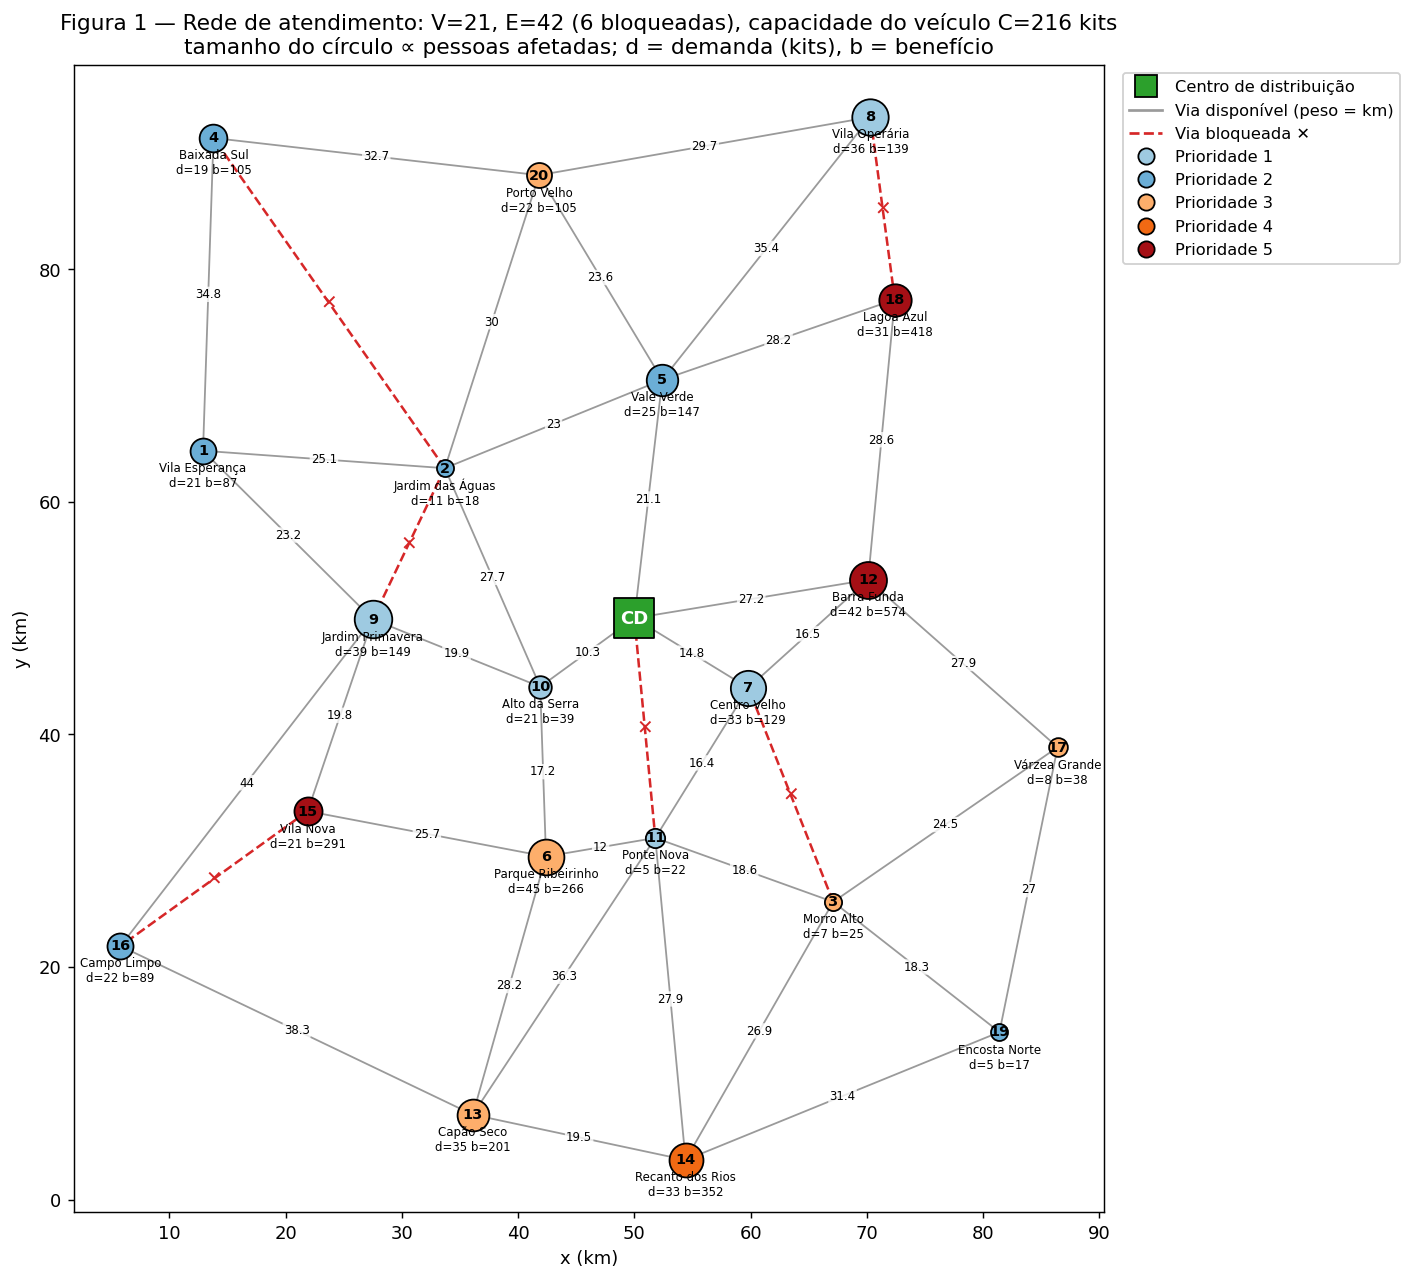

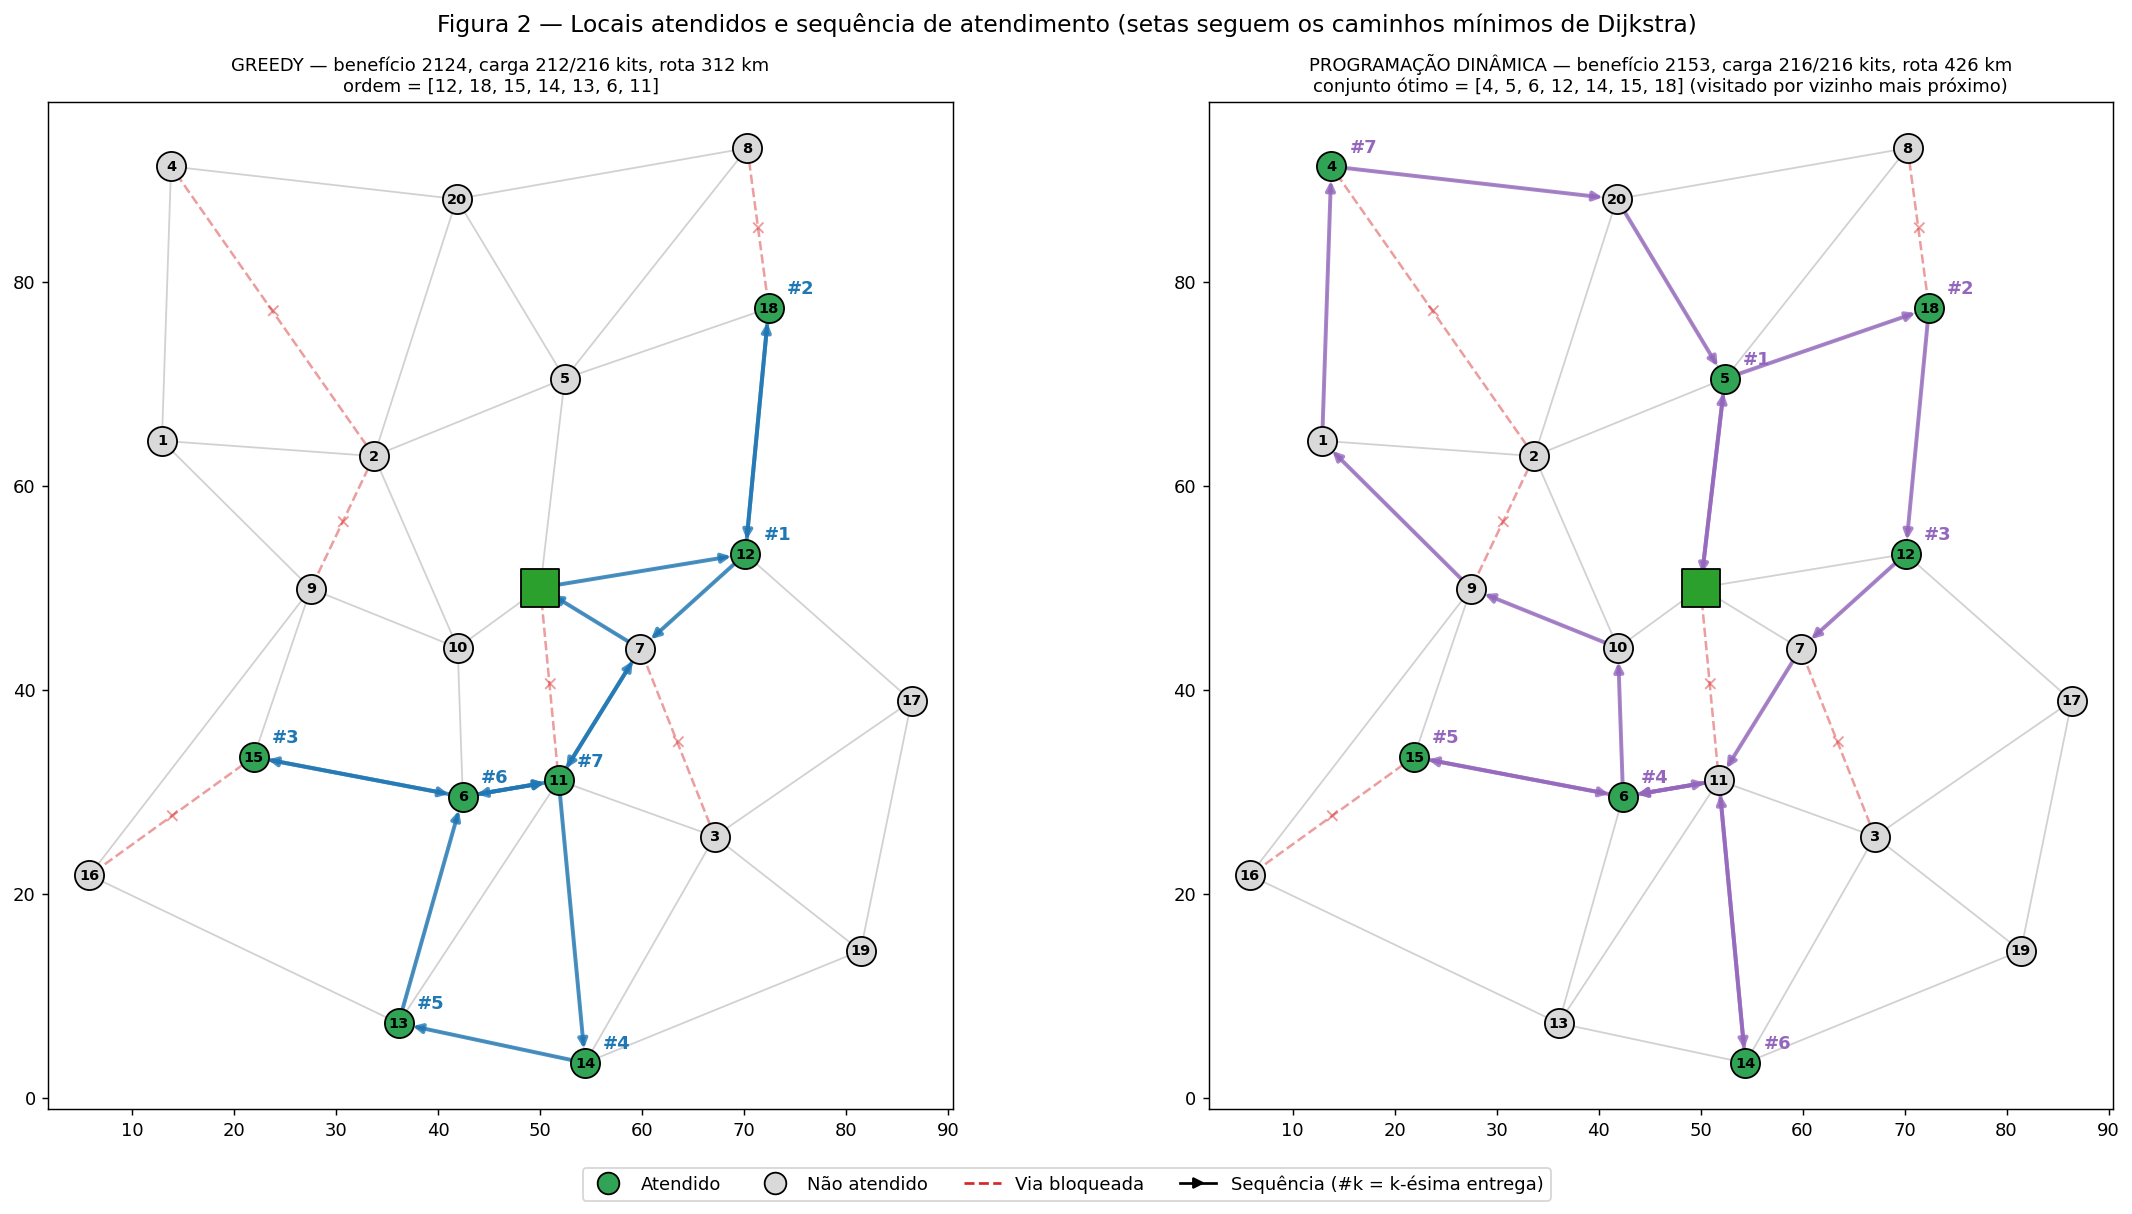

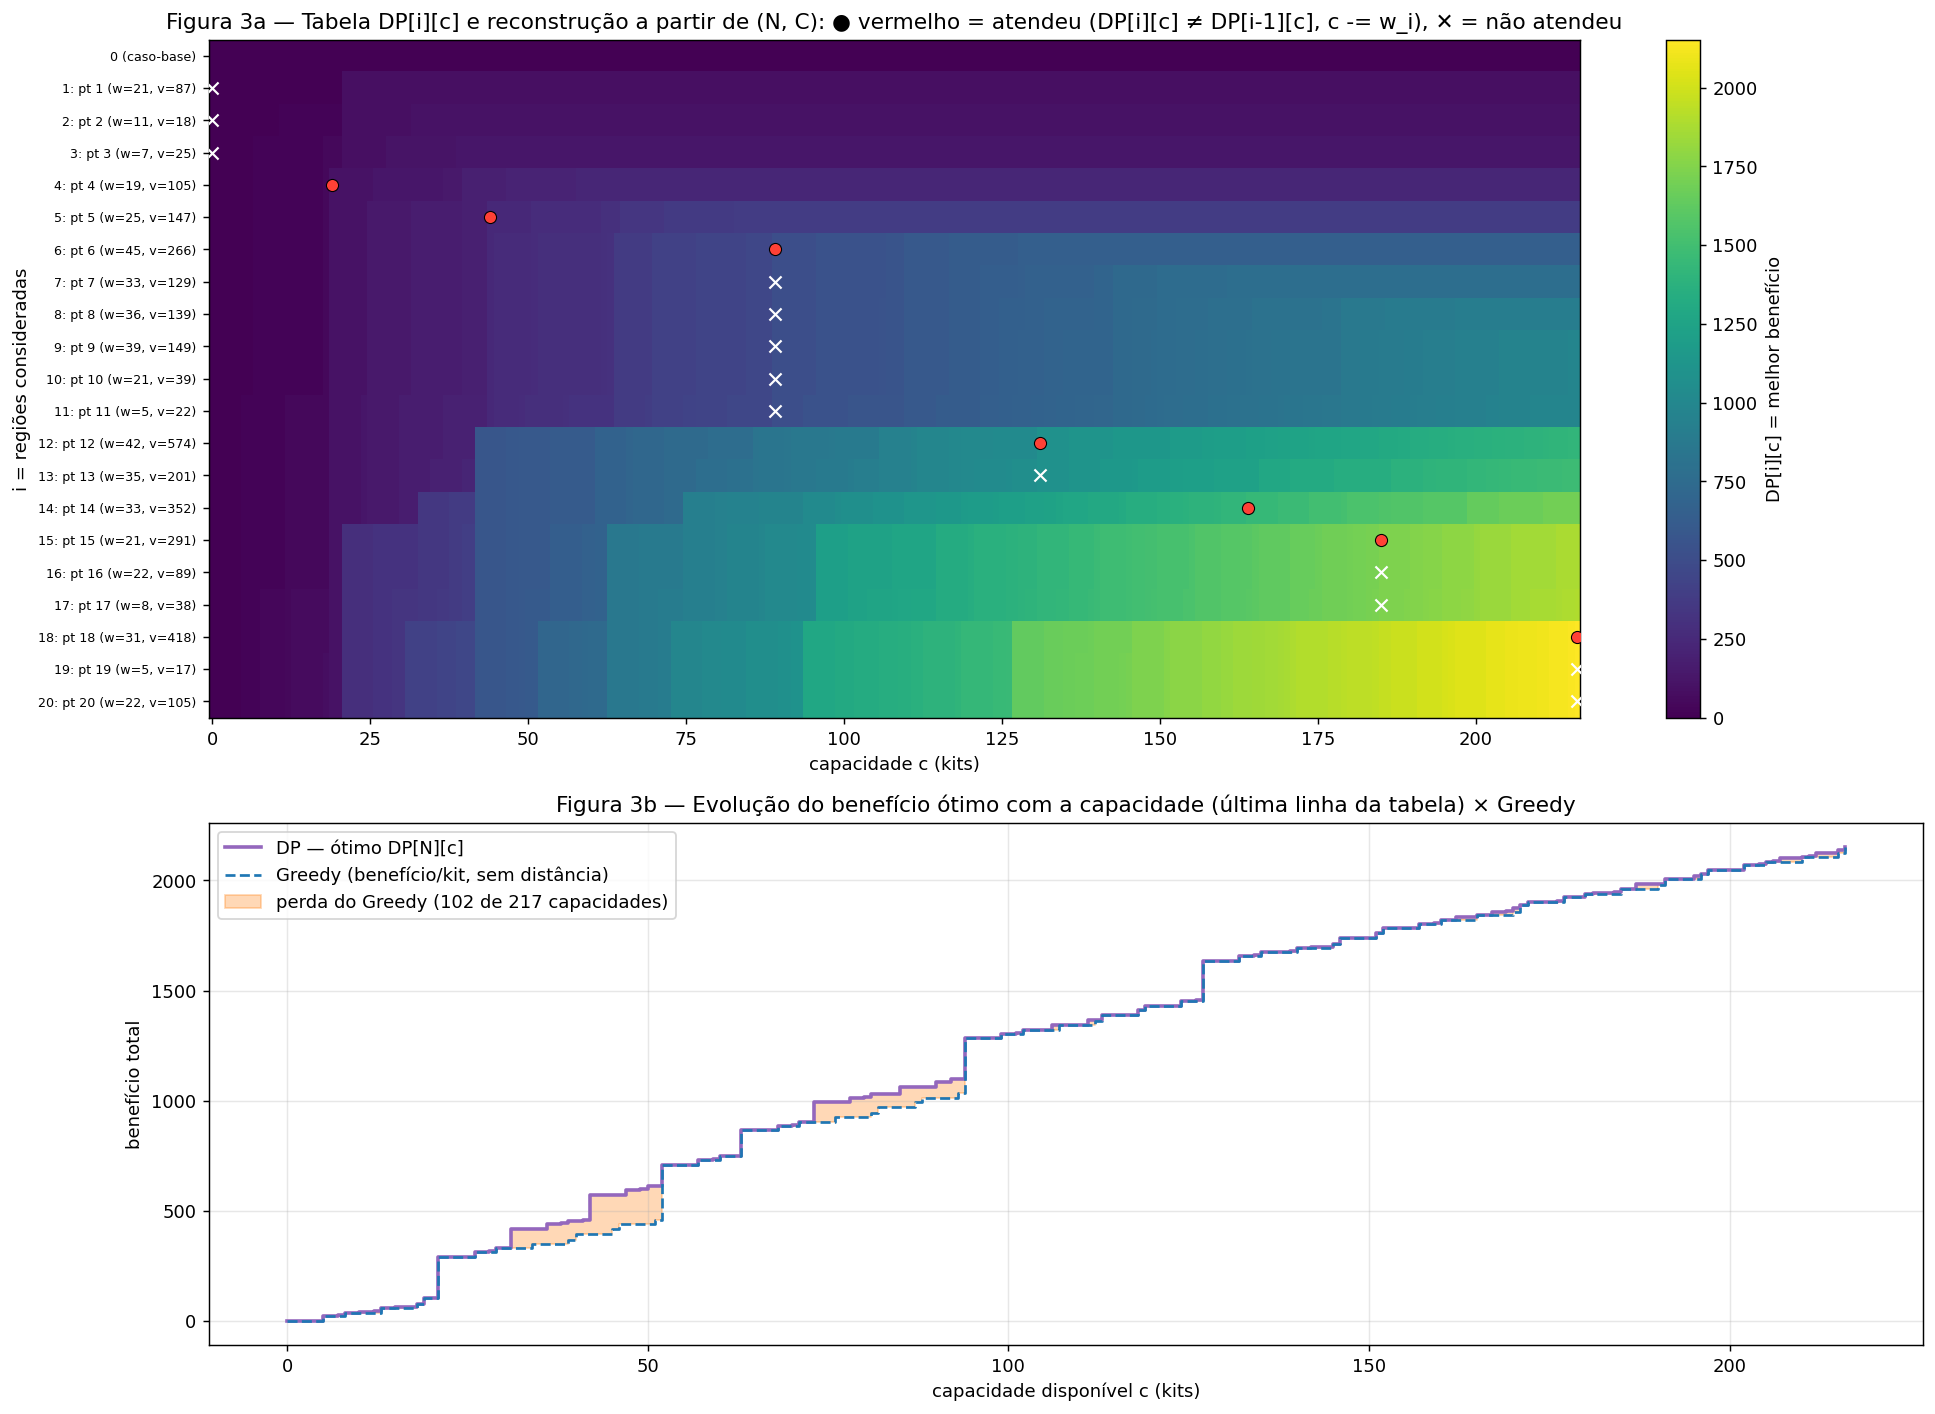

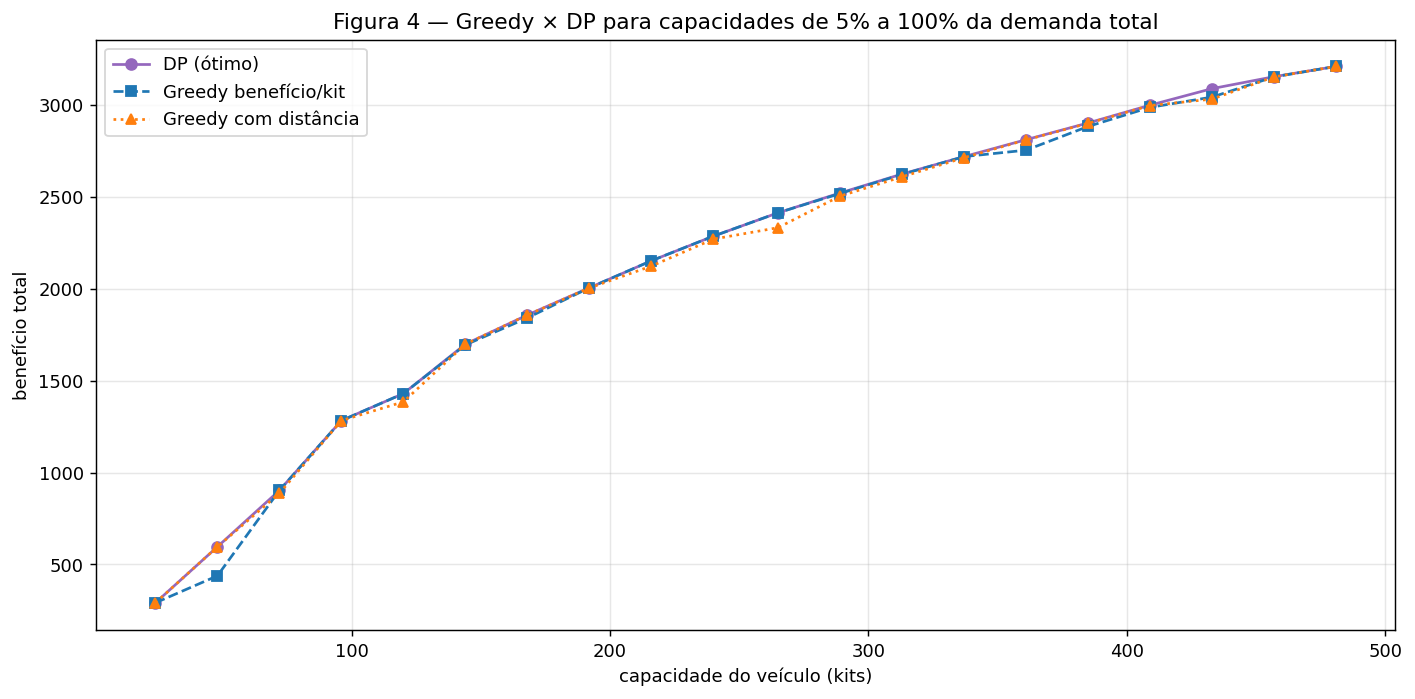

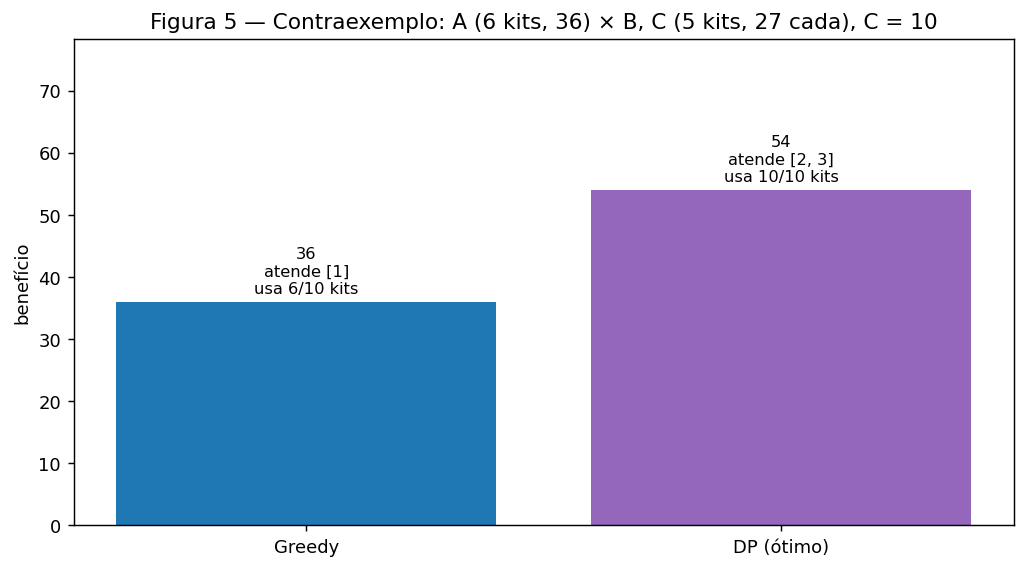

In [9]:
from src.questao1 import resolver
resumo = resolver(grafo, capacidade, figuras=True)
for nome in ["fig1_grafo", "fig2_solucao", "fig3_programacao_dinamica", "fig4_greedy_vs_dp_capacidades", "fig5_contraexemplo"]:
    display(Image(filename=str(FIG_DIR / "questao1" / f"{nome}.png")))

## Parte F — Complexidade (verificação empírica)

* Dijkstra: O((V + E) log V) por origem.
* Greedy: até N+1 Dijkstras (um por posição do veículo) + N passos × varredura de N candidatos → **O(N·(V+E) log V + N²)**.
* DP: N·(C+1) células, O(1) cada → **O(N·C)** tempo e espaço (O(C) sem reconstrução).

Abaixo contamos o que de fato aconteceu:

In [10]:
import time
from src.dynamic_programming import mochila_dp_1d

m2 = MatrizDistancias(grafo)
guloso_atendimento(grafo, capacidade, matriz=m2)
print("Dijkstras executados pelo Greedy:", m2.execucoes, "(≤ N+1 =", len(itens) + 1, ")")
for C in [100, 200, 400, 800, 1600]:
    t = time.perf_counter(); mochila_dp(itens, C); t = time.perf_counter() - t
    print(f"C = {C:>5}: {len(itens)*(C+1):>7} células, {t*1000:6.2f} ms → {t/(len(itens)*(C+1))*1e9:5.0f} ns/célula")
print("Valor com DP 1D (memória O(C)):", mochila_dp_1d(itens, capacidade))

Dijkstras executados pelo Greedy: 8 (≤ N+1 = 21 )
C =   100:    2020 células,   0.15 ms →    74 ns/célula
C =   200:    4020 células,   0.28 ms →    70 ns/célula
C =   400:    8020 células,   0.70 ms →    88 ns/célula
C =   800:   16020 células,   1.61 ms →   101 ns/célula
C =  1600:   32020 células,   3.07 ms →    96 ns/célula
Valor com DP 1D (memória O(C)): 2153


O tempo por célula é aproximadamente constante → o custo cresce linearmente com C, como previsto por O(N·C).

## Simulação de alteração de entrada (preparação para a defesa)

**Previsão antes de rodar:** baixar a prioridade do ponto 12 (Barra Funda) de 5 para 1 reduz seu benefício de 574 para
≈ 143 (fator 4 → 1) e sua densidade de 13,7 para ≈ 3,4 kits. Ele deixa de ser a primeira escolha do Greedy e deve sair
também da solução ótima; os 42 kits liberados vão para pontos de densidade média (ex.: 6, 13). O benefício ótimo deve cair
algo entre 15% e 20% (perde ~430 de benefício e recupera parte com os kits liberados).

In [11]:
import argparse
from src.questao1 import aplicar_alteracoes

g2, cap2 = obter_instancia()
aplicar_alteracoes(g2, argparse.Namespace(bloquear=None, desbloquear=None, peso=None, prioridade=["12=1"]))
r2 = resolver(g2, cap2, figuras=False)
print("Greedy antes :", guloso.ordem, guloso.beneficio)
print("Greedy depois:", r2["guloso"]["ordem"], r2["guloso"]["beneficio"])
print("DP antes :", sorted(dp.selecionados), dp.beneficio)
print("DP depois:", r2["dp"]["selecionados"], r2["dp"]["beneficio"], f"({100*(r2['dp']['beneficio']/dp.beneficio-1):.1f}%)")

Greedy antes : [12, 18, 15, 14, 13, 6, 11] 2124
Greedy depois: [15, 14, 18, 5, 20, 4, 1, 9, 11] 1676
DP antes : [4, 5, 6, 12, 14, 15, 18] 2153
DP depois: [3, 4, 5, 6, 13, 14, 15, 18] 1805 (-16.2%)
